# Week 3 - Spotify Data Analysis

## Before Cleaning vs After Cleaning Comparison

**Dataset:** Spotify Songs

**Objective:** Compare the original Spotify dataset with the cleaned dataset to evaluate the effect of missing-value handling and other cleaning steps.

This notebook focuses on:
- Missing-value comparison
- Distribution comparison
- Boxplot comparison
- Descriptive-statistics comparison
- Outlier comparison using Z-score
- Final observations and conclusion


## 1. Import Libraries

The libraries below are used for data handling, numerical analysis, and visualization.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load Original and Cleaned Datasets

The original dataset is loaded from Kaggle using KaggleHub. The cleaned dataset is loaded from `spotify_cleaned_week3.csv`, which was created during the Week 3 cleaning stage.

In [9]:
import kagglehub
import os

path = kagglehub.dataset_download("nikitatkachenko/19332-spotify-songs")

original_df = pd.read_csv(
    os.path.join(path, "19332_Spotify_Songs.csv"),
    encoding="latin1"
)

cleaned_df = pd.read_csv(
    r"C:\Users\Tejus\Desktop\DSV_PROJECT_TEAM_9\spotify_cleaned_week3.csv"
)

print("Original dataset shape:", original_df.shape)
print("Cleaned dataset shape:", cleaned_df.shape)

C:\Users\Tejus\AppData\Local\Temp\ipykernel_984\2259859144.py:6: DtypeWarning: Columns (9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  original_df = pd.read_csv(


Original dataset shape: (19335, 46)
Cleaned dataset shape: (19335, 45)


C:\Users\Tejus\AppData\Local\Temp\ipykernel_984\2259859144.py:11: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned_df = pd.read_csv(


## 3. Dataset Preview

The first few rows of both datasets are displayed to verify that they were loaded correctly.

In [10]:
display(original_df.head())
display(cleaned_df.head())

,id,artists,available_markets,disc_number,duration_ms.x,explicit,href,is_local,name,popularity,...,instrumentalness,liveness,valence,tempo,type.y,uri.y,track_href,analysis_url,duration_ms.y,time_signature
0,000xQL6tZNLJzIrtIgxqSl,https://api.spotify.com/v1/artists/5ZsFI1h6hId...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,188490,FALSE,https://api.spotify.com/v1/tracks/000xQL6tZNLJ...,FALSE,Still Got Time (feat. PARTYNEXTDOOR),63,...,0.000000,0.0852,0.524,120.963,audio_features,spotify:track:000xQL6tZNLJzIrtIgxqSl,https://api.spotify.com/v1/tracks/000xQL6tZNLJ...,https://api.spotify.com/v1/audio-analysis/000x...,188491.0,4.0
1,001UkMQHw4zXfFNdKpwXAF,https://api.spotify.com/v1/artists/0XKOBt59crn...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,191053,FALSE,https://api.spotify.com/v1/tracks/001UkMQHw4zX...,FALSE,Brand New Man - with Luke Combs,68,...,0.000079,0.2900,0.562,127.061,audio_features,spotify:track:001UkMQHw4zXfFNdKpwXAF,https://api.spotify.com/v1/tracks/001UkMQHw4zX...,https://api.spotify.com/v1/audio-analysis/001U...,191053.0,4.0
2,003FTlCpBTM4eSqYSWPv4H,https://api.spotify.com/v1/artists/3vAaWhdBR38...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,233266,FALSE,https://api.spotify.com/v1/tracks/003FTlCpBTM4...,FALSE,"Swing, Swing",67,...,0.128000,0.0385,0.318,127.947,audio_features,spotify:track:003FTlCpBTM4eSqYSWPv4H,https://api.spotify.com/v1/tracks/003FTlCpBTM4...,https://api.spotify.com/v1/audio-analysis/003F...,233267.0,4.0
3,003vvx7Niy0yvhvHt4a68B,https://api.spotify.com/v1/artists/0C0XlULifJt...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,222973,FALSE,https://api.spotify.com/v1/tracks/003vvx7Niy0y...,FALSE,Mr. Brightside,80,...,0.000000,0.0995,0.236,148.033,audio_features,spotify:track:003vvx7Niy0yvhvHt4a68B,https://api.spotify.com/v1/tracks/003vvx7Niy0y...,https://api.spotify.com/v1/audio-analysis/003v...,222973.0,4.0
4,005lwxGU1tms6HGELIcUv9,https://api.spotify.com/v1/artists/6jJ0s89eD6G...,"CA, JP, US",1,179640,FALSE,https://api.spotify.com/v1/tracks/005lwxGU1tms...,FALSE,I Kissed A Girl,68,...,0.000000,0.1320,0.696,129.996,audio_features,spotify:track:005lwxGU1tms6HGELIcUv9,https://api.spotify.com/v1/tracks/005lwxGU1tms...,https://api.spotify.com/v1/audio-analysis/005l...,179640.0,4.0


,id,artists,available_markets,disc_number,duration_ms.x,explicit,href,is_local,name,popularity,...,instrumentalness,liveness,valence,tempo,type.y,uri.y,track_href,analysis_url,duration_ms.y,time_signature
0,000xQL6tZNLJzIrtIgxqSl,https://api.spotify.com/v1/artists/5ZsFI1h6hId...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,188490,FALSE,https://api.spotify.com/v1/tracks/000xQL6tZNLJ...,FALSE,Still Got Time (feat. PARTYNEXTDOOR),63,...,0.000000,0.0852,0.524,120.963,audio_features,spotify:track:000xQL6tZNLJzIrtIgxqSl,https://api.spotify.com/v1/tracks/000xQL6tZNLJ...,https://api.spotify.com/v1/audio-analysis/000x...,188491.0,4.0
1,001UkMQHw4zXfFNdKpwXAF,https://api.spotify.com/v1/artists/0XKOBt59crn...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,191053,FALSE,https://api.spotify.com/v1/tracks/001UkMQHw4zX...,FALSE,Brand New Man - with Luke Combs,68,...,0.000079,0.2900,0.562,127.061,audio_features,spotify:track:001UkMQHw4zXfFNdKpwXAF,https://api.spotify.com/v1/tracks/001UkMQHw4zX...,https://api.spotify.com/v1/audio-analysis/001U...,191053.0,4.0
2,003FTlCpBTM4eSqYSWPv4H,https://api.spotify.com/v1/artists/3vAaWhdBR38...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,233266,FALSE,https://api.spotify.com/v1/tracks/003FTlCpBTM4...,FALSE,"Swing, Swing",67,...,0.128000,0.0385,0.318,127.947,audio_features,spotify:track:003FTlCpBTM4eSqYSWPv4H,https://api.spotify.com/v1/tracks/003FTlCpBTM4...,https://api.spotify.com/v1/audio-analysis/003F...,233267.0,4.0
3,003vvx7Niy0yvhvHt4a68B,https://api.spotify.com/v1/artists/0C0XlULifJt...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,222973,FALSE,https://api.spotify.com/v1/tracks/003vvx7Niy0y...,FALSE,Mr. Brightside,80,...,0.000000,0.0995,0.236,148.033,audio_features,spotify:track:003vvx7Niy0yvhvHt4a68B,https://api.spotify.com/v1/tracks/003vvx7Niy0y...,https://api.spotify.com/v1/audio-analysis/003v...,222973.0,4.0
4,005lwxGU1tms6HGELIcUv9,https://api.spotify.com/v1/artists/6jJ0s89eD6G...,"CA, JP, US",1,179640,FALSE,https://api.spotify.com/v1/tracks/005lwxGU1tms...,FALSE,I Kissed A Girl,68,...,0.000000,0.1320,0.696,129.996,audio_features,spotify:track:005lwxGU1tms6HGELIcUv9,https://api.spotify.com/v1/tracks/005lwxGU1tms...,https://api.spotify.com/v1/audio-analysis/005l...,179640.0,4.0


## 4. Selected Audio Features

The comparison focuses on the main Spotify audio features used during the cleaning stage.

In [11]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

## 5. Missing Value Comparison

Missing values can affect statistical analysis and visualization. We compare the selected numerical audio features before and after cleaning.

During the cleaning stage, missing numerical values were handled using **median imputation**.

In [12]:
missing_before = original_df[audio_features].isnull().sum()
missing_after = cleaned_df[audio_features].isnull().sum()

missing_comparison = pd.DataFrame({
    "Before Cleaning": missing_before,
    "After Cleaning": missing_after
})

missing_comparison

,Before Cleaning,After Cleaning
danceability,7,0
energy,7,0
loudness,7,0
speechiness,7,0
acousticness,7,0
instrumentalness,7,0
liveness,7,0
valence,7,0
tempo,7,0


### 5.1 Missing Values Before vs After Cleaning

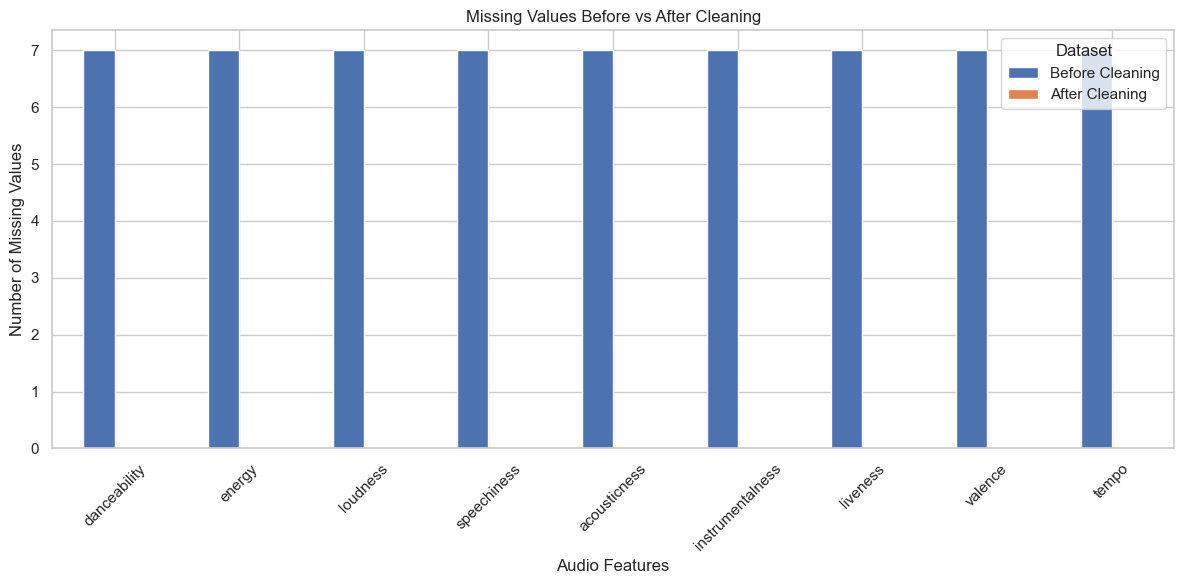

In [13]:
plt.figure(figsize=(12, 6))

missing_comparison.plot(
    kind="bar",
    ax=plt.gca()
)

plt.title("Missing Values Before vs After Cleaning")
plt.xlabel("Audio Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

### Observation

Before cleaning, the selected numerical audio features contained missing values. After median imputation, the missing values were reduced to zero. No rows were removed for these missing numerical values.

## 6. Distribution Comparison

Distribution comparison helps determine whether the cleaning process caused a major change in the overall pattern of a variable.

The following comparisons use overlapping histograms with KDE curves.

In [14]:
def compare_distribution(column, title, xlabel):
    plt.figure(figsize=(10, 6))

    sns.histplot(
        original_df[column].dropna(),
        bins=30,
        kde=True,
        alpha=0.40,
        label="Before Cleaning"
    )

    sns.histplot(
        cleaned_df[column].dropna(),
        bins=30,
        kde=True,
        alpha=0.40,
        label="After Cleaning"
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of Songs")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Danceability Distribution

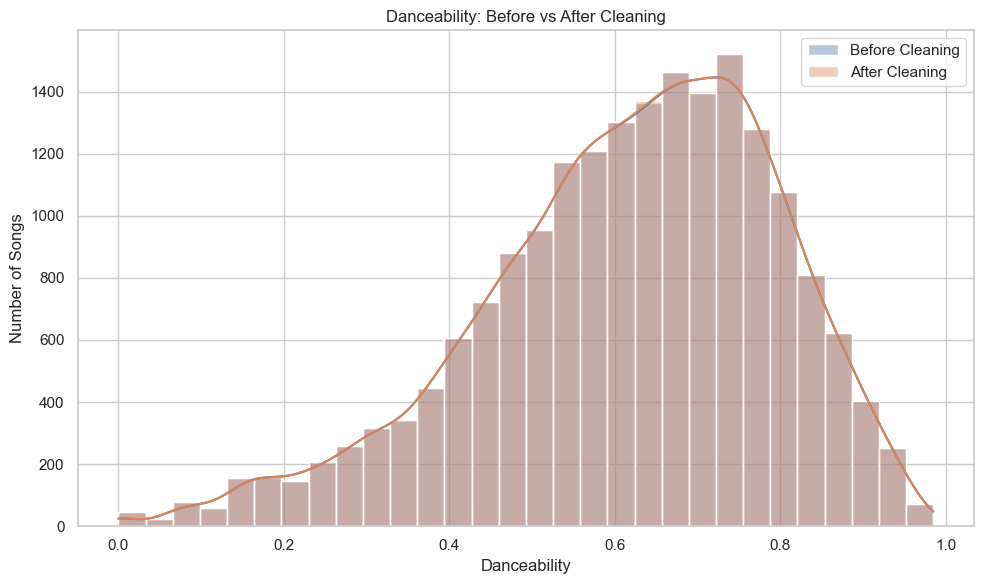

In [15]:
compare_distribution("danceability", "Danceability: Before vs After Cleaning", "Danceability")

**Observation:** The before-cleaning and after-cleaning distributions of `danceability` can be compared to check whether imputation caused any substantial shift. Because only a small number of values were imputed, the overall distribution should remain largely similar.

### Energy Distribution

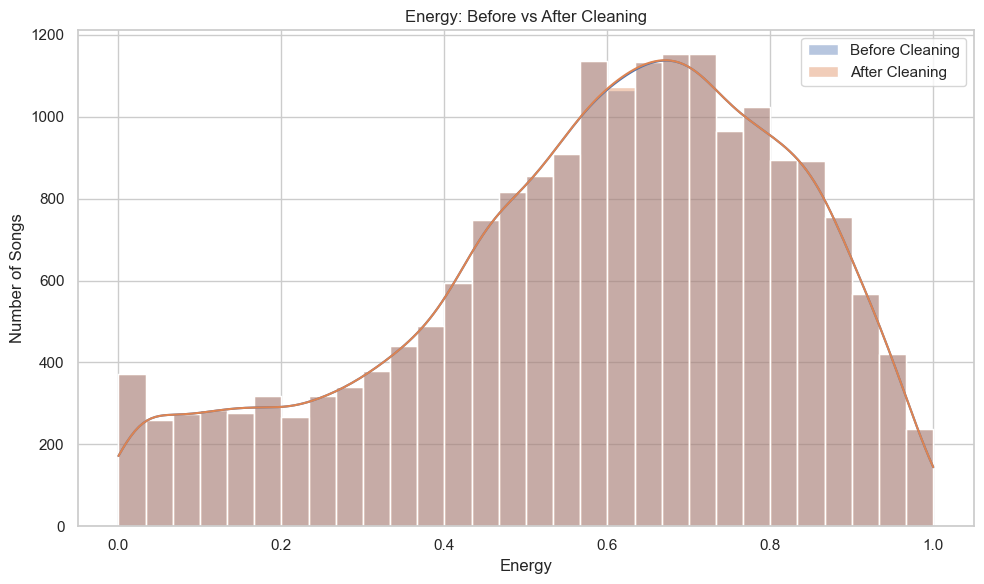

In [16]:
compare_distribution("energy", "Energy: Before vs After Cleaning", "Energy")

**Observation:** The before-cleaning and after-cleaning distributions of `energy` can be compared to check whether imputation caused any substantial shift. Because only a small number of values were imputed, the overall distribution should remain largely similar.

### Tempo Distribution

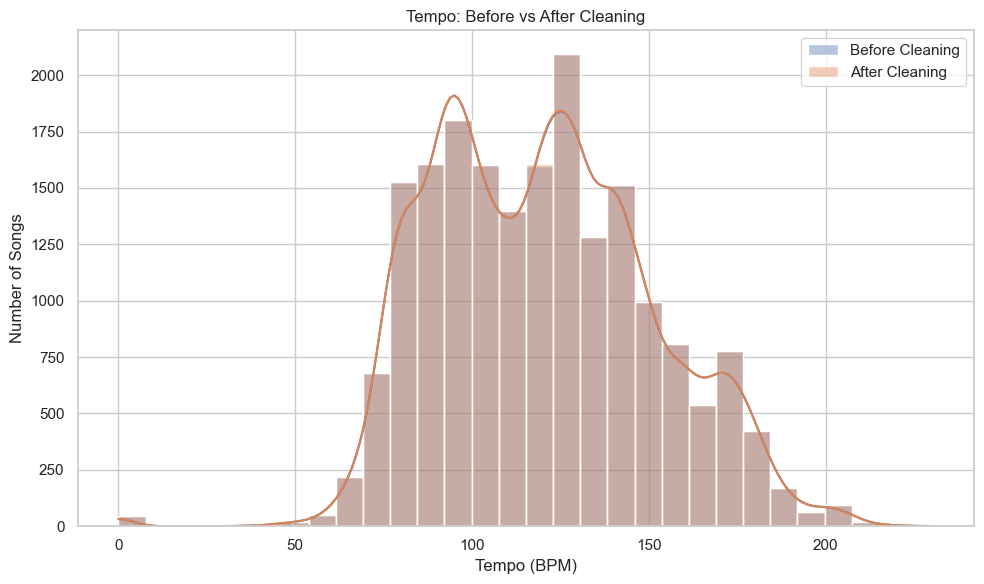

In [17]:
compare_distribution("tempo", "Tempo: Before vs After Cleaning", "Tempo (BPM)")

**Observation:** The before-cleaning and after-cleaning distributions of `tempo` can be compared to check whether imputation caused any substantial shift. Because only a small number of values were imputed, the overall distribution should remain largely similar.

## 7. Boxplot Comparison

Boxplots show the median, interquartile range, whiskers, and potential extreme values. Comparing the boxplots before and after cleaning helps determine whether the cleaning process substantially changed the spread of the data.

In [18]:
def compare_boxplot(column, title, xlabel):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.boxplot(x=original_df[column], ax=axes[0])
    axes[0].set_title("Before Cleaning")
    axes[0].set_xlabel(xlabel)

    sns.boxplot(x=cleaned_df[column], ax=axes[1])
    axes[1].set_title("After Cleaning")
    axes[1].set_xlabel(xlabel)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### Danceability Boxplot

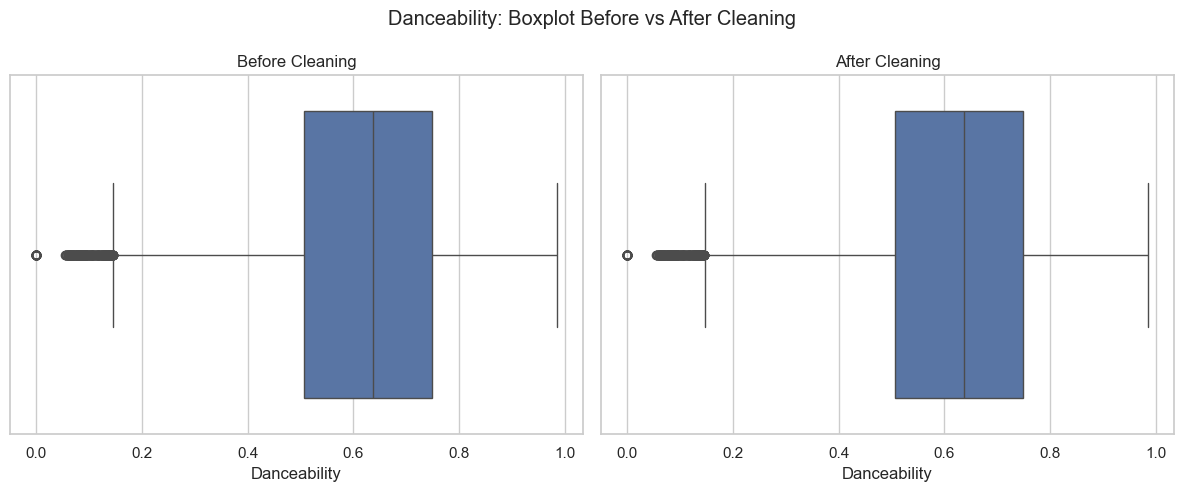

In [19]:
compare_boxplot("danceability", "Danceability: Boxplot Before vs After Cleaning", "Danceability")

### Energy Boxplot

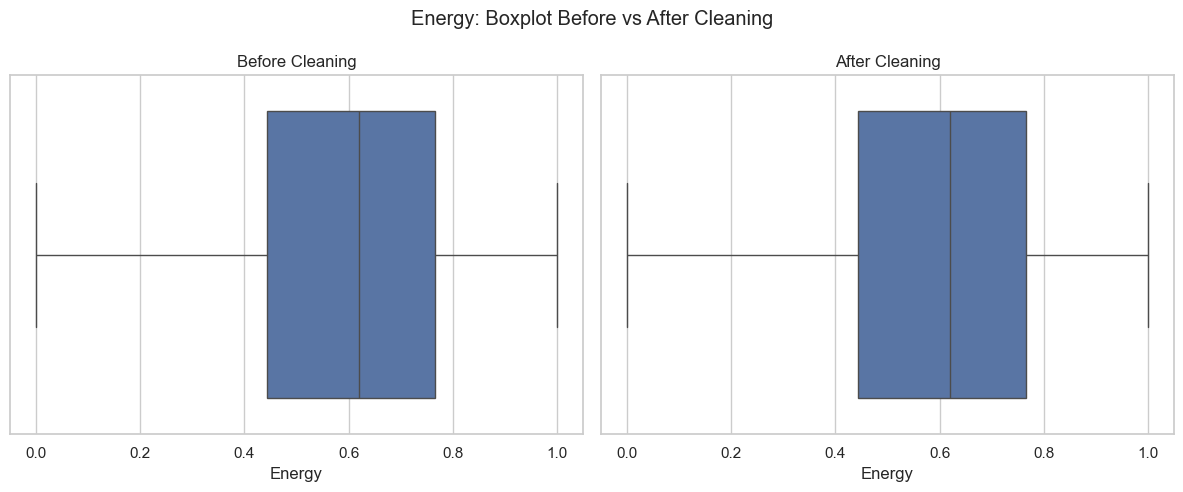

In [20]:
compare_boxplot("energy", "Energy: Boxplot Before vs After Cleaning", "Energy")

### Tempo Boxplot

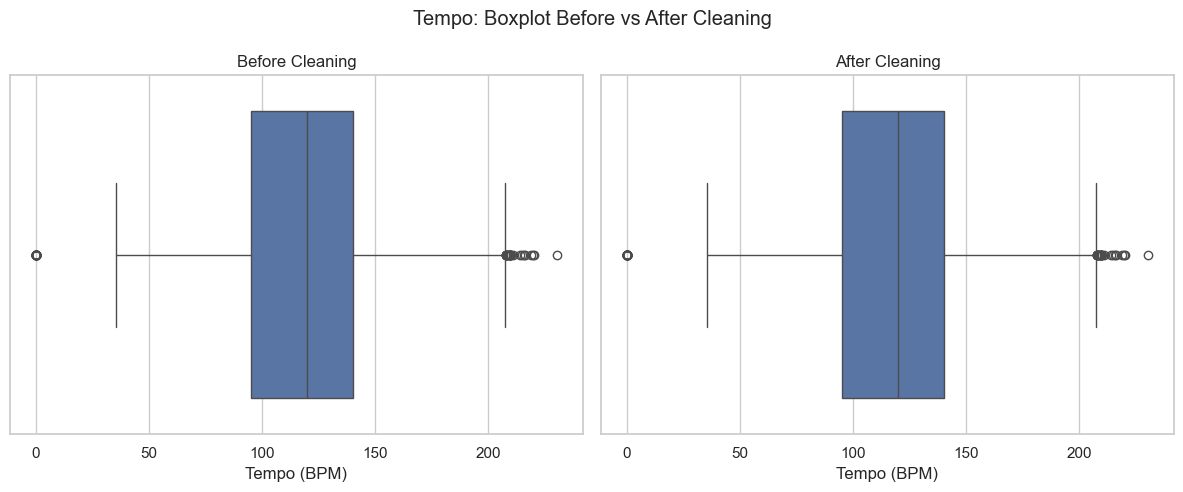

In [21]:
compare_boxplot("tempo", "Tempo: Boxplot Before vs After Cleaning", "Tempo (BPM)")

### Observation

The boxplots can be compared to check whether the median, spread, and potential outlier pattern changed after cleaning. The outliers are not automatically removed because extreme Spotify audio values can represent legitimate songs.

## 8. Descriptive Statistics Comparison

Descriptive statistics summarize the central tendency and spread of the audio features. Comparing the mean, standard deviation, median, minimum, and maximum helps evaluate whether cleaning changed the data substantially.

In [22]:
before_stats = original_df[audio_features].describe().T
after_stats = cleaned_df[audio_features].describe().T

stats_comparison = pd.DataFrame({
    "Mean Before": before_stats["mean"],
    "Mean After": after_stats["mean"],
    "Median Before": before_stats["50%"],
    "Median After": after_stats["50%"],
    "Std Before": before_stats["std"],
    "Std After": after_stats["std"]
})

stats_comparison.round(4)

,Mean Before,Mean After,Median Before,Median After,Std Before,Std After
danceability,0.6160,0.6160,0.6380,0.6380,0.1799,0.1798
energy,0.5842,0.5842,0.6200,0.6200,0.2369,0.2369
loudness,-8.6054,-8.6047,-6.8160,-6.8160,5.8036,5.8026
speechiness,0.1073,0.1073,0.0565,0.0565,0.1118,0.1117
acousticness,0.3087,0.3086,0.1750,0.1750,0.3219,0.3219
instrumentalness,0.1022,0.1021,0.0000,0.0000,0.2670,0.2669
liveness,0.1825,0.1824,0.1220,0.1220,0.1471,0.1471
valence,0.4914,0.4914,0.4900,0.4900,0.2428,0.2427
tempo,119.7949,119.7949,119.8945,119.8945,30.9726,30.9670


### 8.1 Mean Comparison

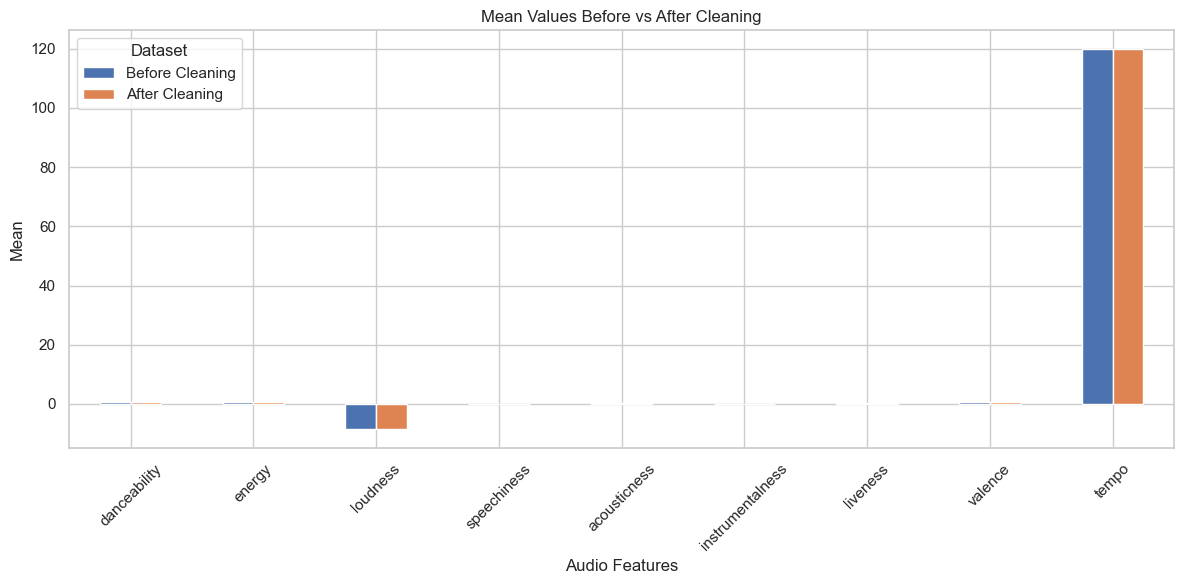

In [23]:
mean_comparison = pd.DataFrame({
    "Before Cleaning": before_stats["mean"],
    "After Cleaning": after_stats["mean"]
})

mean_comparison.plot(kind="bar", figsize=(12, 6))
plt.title("Mean Values Before vs After Cleaning")
plt.xlabel("Audio Features")
plt.ylabel("Mean")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

### 8.2 Standard Deviation Comparison

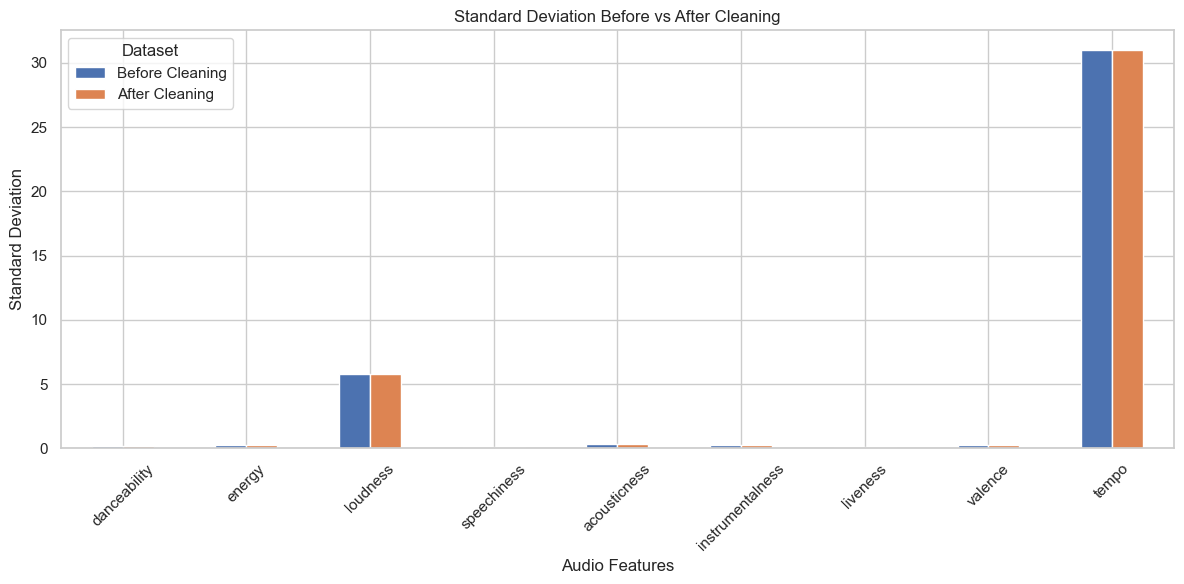

In [24]:
std_comparison = pd.DataFrame({
    "Before Cleaning": before_stats["std"],
    "After Cleaning": after_stats["std"]
})

std_comparison.plot(kind="bar", figsize=(12, 6))
plt.title("Standard Deviation Before vs After Cleaning")
plt.xlabel("Audio Features")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

### Observation

The descriptive statistics show how the central tendency and spread changed after cleaning. Since only a small number of numerical values were imputed, the summary statistics are expected to remain very similar.

## 9. Outlier Comparison Using Z-Score

A Z-score measures how far an observation is from the mean in standard-deviation units.

For this analysis, observations with an absolute Z-score greater than 3 are treated as **potential outliers**.

This comparison shows whether the number of detected potential outliers changed after imputation.

In [25]:
from scipy.stats import zscore

before_z = original_df[audio_features].apply(lambda s: zscore(s, nan_policy="omit"))
after_z = cleaned_df[audio_features].apply(lambda s: zscore(s, nan_policy="omit"))

outliers_before = (before_z.abs() > 3).sum()
outliers_after = (after_z.abs() > 3).sum()

outlier_comparison = pd.DataFrame({
    "Before Cleaning": outliers_before,
    "After Cleaning": outliers_after
})

outlier_comparison

,Before Cleaning,After Cleaning
danceability,90,90
energy,0,0
loudness,479,479
speechiness,336,336
acousticness,0,0
instrumentalness,871,886
liveness,524,524
valence,0,0
tempo,53,53


### 9.1 Potential Outliers Before vs After Cleaning

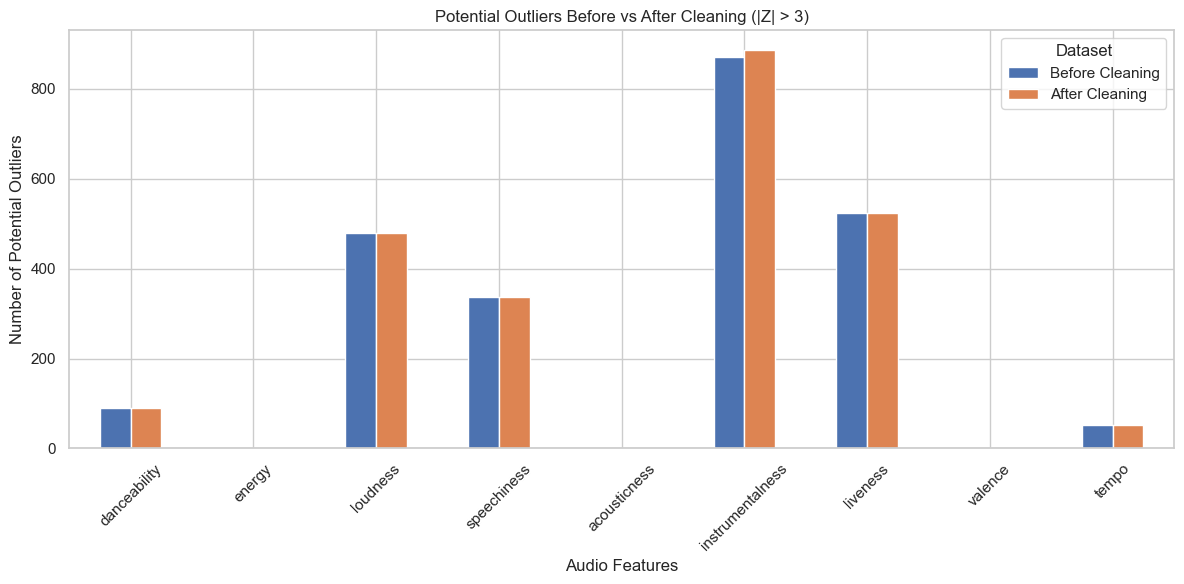

In [26]:
outlier_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Potential Outliers Before vs After Cleaning (|Z| > 3)")
plt.xlabel("Audio Features")
plt.ylabel("Number of Potential Outliers")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

### Observation

The Z-score comparison shows whether imputation changed the number of potential outliers. Imputation does not necessarily remove existing outliers; it mainly fills missing values. Therefore, most of the existing outlier pattern can remain unchanged.

## 10. Correlation Comparison

Correlation measures the strength and direction of the linear relationship between two numerical variables.

A heatmap is used to compare the correlation structure before and after cleaning.

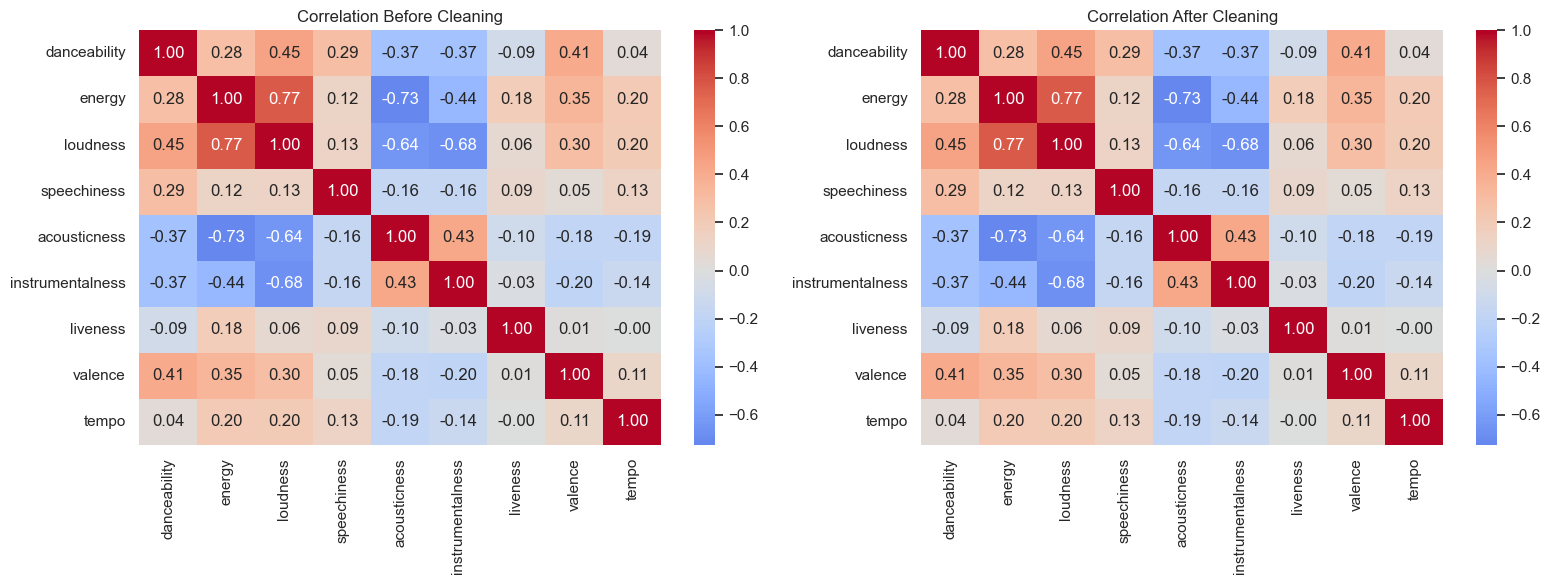

In [27]:
corr_before = original_df[audio_features].corr()
corr_after = cleaned_df[audio_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    corr_before,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("Correlation Before Cleaning")

sns.heatmap(
    corr_after,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    ax=axes[1]
)
axes[1].set_title("Correlation After Cleaning")

plt.tight_layout()
plt.show()

### Observation

The two heatmaps can be compared to determine whether the relationships among the main audio features changed after cleaning. Because only a small number of values were imputed, the overall correlation structure should remain similar.

## 11. Final Verification

The cleaned dataset is checked to confirm that the selected numerical audio features contain no missing values.

In [28]:
print("Missing values before cleaning:")
print(original_df[audio_features].isnull().sum())
print("\nMissing values after cleaning:")
print(cleaned_df[audio_features].isnull().sum())

Missing values before cleaning:
danceability        7
energy              7
loudness            7
speechiness         7
acousticness        7
instrumentalness    7
liveness            7
valence             7
tempo               7
dtype: int64

Missing values after cleaning:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64


## 12. Conclusion

The original and cleaned Spotify datasets were compared using missing-value counts, distributions, boxplots, descriptive statistics, Z-score outlier detection, and correlation heatmaps.

The comparison shows that the cleaning process successfully handled missing values in the selected numerical audio features through median imputation. The overall distributions and statistical characteristics remain broadly similar, indicating that the imputation did not substantially distort the dataset.

Potential outliers were identified using the |Z| > 3 rule but were not automatically removed because extreme audio-feature values may represent legitimate songs. The correlation structure was also compared before and after cleaning to evaluate whether data cleaning materially affected relationships between features.

Overall, the cleaned dataset is suitable for further Exploratory Data Analysis and visualization.